# STUDENT ANALYSIS

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [15]:
output_folder = "charts"
os.makedirs(output_folder, exist_ok=True)

In [16]:
sns.set(style="whitegrid")

In [17]:
print("Libraries loaded successfully.")
#FOR TESTING IF IT IS LOADED

Libraries loaded successfully.


In [18]:
df = pd.read_csv("../data/processed/student_full_data.csv", sep=';')

In [19]:
df.head()

,student_id,age,gender,academic_level,part_time_job,study_hours,self_study_hours,online_classes_hours,upcoming_deadline,sleep_hours,...,gaming_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,internet_quality,productivity_score,exam_score,mental_health_score,focus_index,burnout_level
0,1,18,Other,High School,1,7.64,1.56,2.20,0,6.52,...,2.19,6.47,81,38,Good,73.65,50.16,10.0,43.05,31.77
1,2,18,Other,High School,0,2.21,2.22,2.10,0,5.97,...,2.55,6.05,111,339,Good,13.70,1.00,3.0,15.92,37.00
2,3,22,Male,High School,0,3.45,0.00,0.29,1,8.39,...,2.08,7.62,68,266,Good,45.15,18.30,8.0,27.39,34.37
3,4,17,Other,High School,1,5.75,2.08,3.01,1,6.31,...,2.20,11.67,113,480,Poor,20.92,9.37,3.0,22.31,77.31
4,5,19,Other,High School,1,6.83,1.72,3.33,0,8.01,...,0.70,10.02,121,24,Good,59.23,27.81,8.0,38.11,39.53


In [20]:
df.info()
#CHECK STRUCTURE 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   part_time_job         5000 non-null   int64  
 5   study_hours           5000 non-null   float64
 6   self_study_hours      5000 non-null   float64
 7   online_classes_hours  5000 non-null   float64
 8   upcoming_deadline     5000 non-null   int64  
 9   sleep_hours           5000 non-null   float64
 10  social_media_hours    5000 non-null   float64
 11  gaming_hours          5000 non-null   float64
 12  screen_time_hours     5000 non-null   float64
 13  exercise_minutes      5000 non-null   int64  
 14  caffeine_intake_mg    5000 non-null   int64  
 15  internet_quality     

In [21]:
# This will select only the numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

In [22]:
# For this we will compute the correlation matrix
correlation_matrix = numeric_df.corr()

In [23]:
# This will display first few rows
correlation_matrix.head()

,student_id,age,part_time_job,study_hours,self_study_hours,online_classes_hours,upcoming_deadline,sleep_hours,social_media_hours,gaming_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,productivity_score,exam_score,mental_health_score,focus_index,burnout_level
student_id,1.000000,0.015223,0.009575,-0.018550,-0.020115,-0.003989,0.015509,-0.017050,0.019322,0.007484,-0.003596,-0.003271,0.031160,-0.023209,-0.029406,0.008754,-0.010968,0.030547
age,0.015223,1.000000,-0.015375,0.000511,0.004889,-0.001553,-0.004410,0.004719,0.004207,0.013768,0.001662,0.016355,0.000437,-0.013607,-0.009047,-0.023883,-0.018509,-0.013559
part_time_job,0.009575,-0.015375,1.000000,-0.017781,0.017677,-0.013239,0.008010,0.006229,0.002861,-0.015833,0.021273,-0.005723,-0.013010,-0.109907,-0.149807,0.007957,-0.001564,0.372089
study_hours,-0.018550,0.000511,-0.017781,1.000000,-0.003942,0.011238,-0.012726,-0.027995,-0.000296,0.017475,-0.022899,-0.004847,-0.015362,0.637981,0.513434,-0.013122,0.448050,-0.000811
self_study_hours,-0.020115,0.004889,0.017677,-0.003942,1.000000,-0.010100,0.001944,-0.007138,-0.015582,0.000569,-0.016264,0.006304,0.007317,0.057781,0.083602,0.011482,0.237721,0.002670


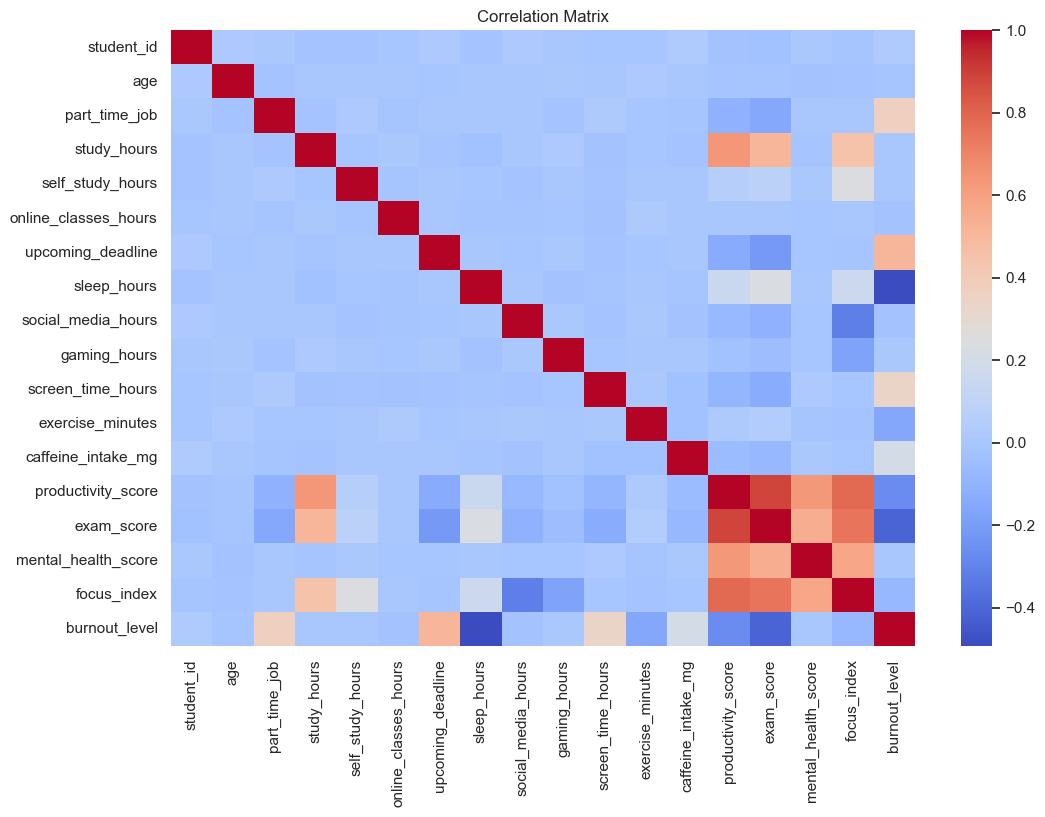

In [25]:
# So for this, we will visualize the correlation
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix")
plt.savefig("charts/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# Correlation with exam_score only
exam_corr = correlation_matrix["exam_score"].sort_values(ascending=False)

exam_corr

exam_score              1.000000
productivity_score      0.886401
focus_index             0.749879
mental_health_score     0.546547
study_hours             0.513434
sleep_hours             0.234710
self_study_hours        0.083602
exercise_minutes        0.040724
online_classes_hours    0.004975
age                    -0.009047
student_id             -0.029406
gaming_hours           -0.054506
caffeine_intake_mg     -0.075586
social_media_hours     -0.106116
screen_time_hours      -0.131940
part_time_job          -0.149807
upcoming_deadline      -0.215342
burnout_level          -0.407808
Name: exam_score, dtype: float64

In [27]:
productivity_corr = correlation_matrix["productivity_score"].sort_values(ascending=False)

productivity_corr

productivity_score      1.000000
exam_score              0.886401
focus_index             0.784956
study_hours             0.637981
mental_health_score     0.630605
sleep_hours             0.149666
self_study_hours        0.057781
exercise_minutes        0.020441
online_classes_hours    0.003215
age                    -0.013607
student_id             -0.023209
gaming_hours           -0.029411
caffeine_intake_mg     -0.056227
social_media_hours     -0.070052
screen_time_hours      -0.089953
part_time_job          -0.109907
upcoming_deadline      -0.140114
burnout_level          -0.267304
Name: productivity_score, dtype: float64

In [28]:
# We will do the same for Exam Score
exam_corr = correlation_matrix["exam_score"].sort_values(ascending=False)
exam_corr

exam_score              1.000000
productivity_score      0.886401
focus_index             0.749879
mental_health_score     0.546547
study_hours             0.513434
sleep_hours             0.234710
self_study_hours        0.083602
exercise_minutes        0.040724
online_classes_hours    0.004975
age                    -0.009047
student_id             -0.029406
gaming_hours           -0.054506
caffeine_intake_mg     -0.075586
social_media_hours     -0.106116
screen_time_hours      -0.131940
part_time_job          -0.149807
upcoming_deadline      -0.215342
burnout_level          -0.407808
Name: exam_score, dtype: float64

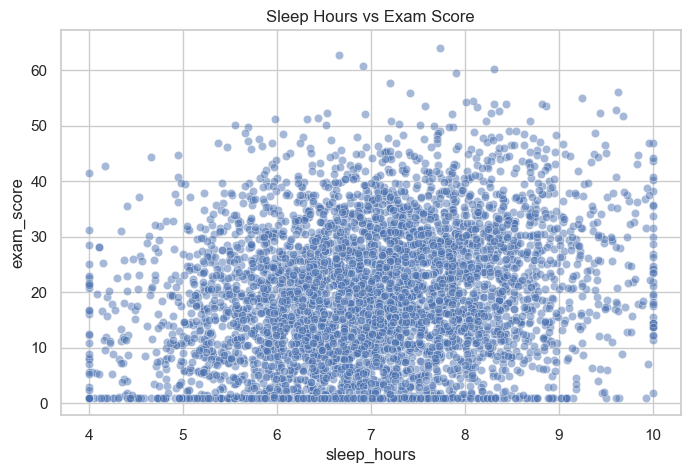

In [44]:
# We will use scatter plot for this one
plt.figure(figsize=(8,5))
sns.scatterplot(x="sleep_hours", y="exam_score", data=df, alpha=0.5)
plt.title("Sleep Hours vs Exam Score")
plt.savefig("charts/sleep_hours_vs_exam_score", dpi=300, bbox_inches="tight")
plt.show()

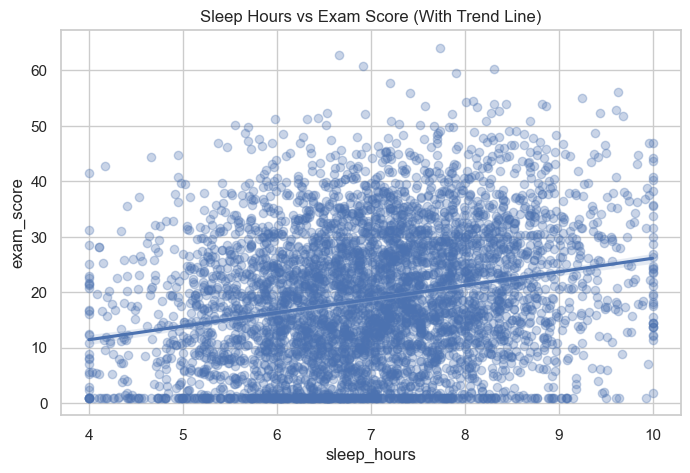

In [45]:
# I will improve the visualization for this one
plt.figure(figsize=(8,5))
sns.regplot(x="sleep_hours", y="exam_score", data=df, scatter_kws={'alpha':0.3})
plt.title("Sleep Hours vs Exam Score (With Trend Line)")
plt.savefig("charts/sleephours_vs_examscore_trendline.png", dpi=300, bbox_inches="tight")
plt.show()

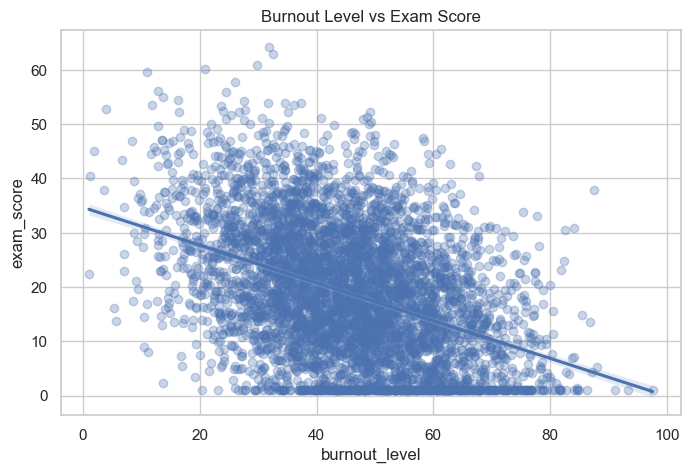

In [46]:
plt.figure(figsize=(8,5))
sns.regplot(x="burnout_level", y="exam_score", data=df, scatter_kws={'alpha':0.3})
plt.title("Burnout Level vs Exam Score")
plt.savefig("charts/burnout_vs_examscore", dpi=300, bbox_inches="tight")
plt.show()


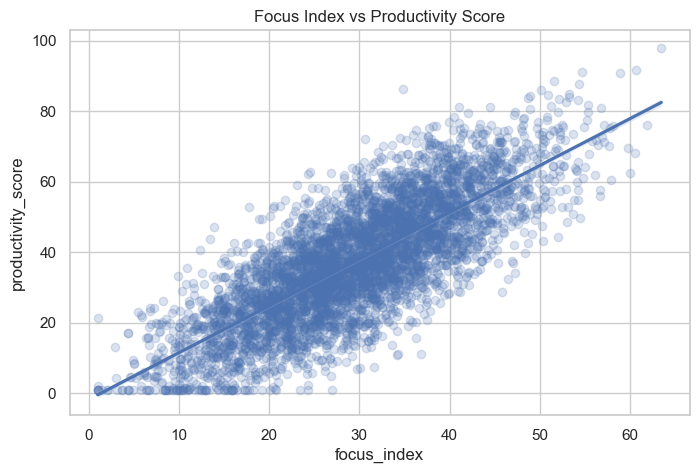

In [48]:
plt.figure(figsize=(8,5))
sns.regplot(x="focus_index", y="productivity_score", data=df, scatter_kws={'alpha':0.2})
plt.title("Focus Index vs Productivity Score")
plt.savefig("charts/focusindex_vs_productivityscore.png", dpi=300, bbox_inches="tight")
plt.show()

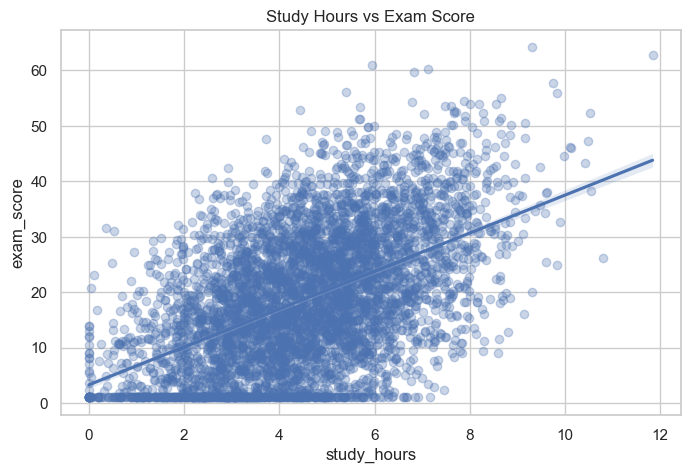

In [47]:
plt.figure(figsize=(8,5))
sns.regplot(x="study_hours", y="exam_score", data=df, scatter_kws={'alpha':0.3})
plt.title("Study Hours vs Exam Score")
plt.savefig("charts/studyhours_vs_examscore.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
#Summarize the statistics for Key Variables
df[["exam_score", "productivity_score", "focus_index", 
    "burnout_level", "study_hours", "sleep_hours"]].describe()

,exam_score,productivity_score,focus_index,burnout_level,study_hours,sleep_hours
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,18.803752,37.267716,29.431616,45.615324,4.539594,7.016492
std,12.130840,16.849397,9.962902,14.246591,1.821665,1.163692
min,1.000000,1.000000,1.000000,1.000000,0.000000,4.000000
25%,9.337500,25.290000,22.567500,35.727500,3.250000,6.237500
50%,18.010000,36.860000,29.430000,45.690000,4.530000,7.010000
75%,27.400000,49.142500,36.242500,55.352500,5.760000,7.810000
max,64.090000,98.020000,63.480000,97.580000,11.840000,10.000000


In [43]:
# I will identify the top 10 Highest Performing Students
top_students = df.sort_values(by="exam_score", ascending=False).head(10)

top_students[["student_id", "exam_score", "study_hours", 
              "sleep_hours", "focus_index", "burnout_level"]]

,student_id,exam_score,study_hours,sleep_hours,focus_index,burnout_level
20,21,64.09,9.31,7.74,60.72,31.88
3375,3376,62.82,11.84,6.66,63.48,32.60
3875,3876,60.85,5.94,6.92,49.94,29.88
3798,3799,60.14,7.13,8.31,54.35,20.88
1545,1546,59.59,6.83,7.91,53.69,10.91
4351,4352,57.75,9.75,7.20,58.94,26.05
1040,1041,56.09,5.41,9.63,38.87,12.85
493,494,55.96,9.84,7.42,57.10,24.46
4481,4482,54.97,8.65,9.25,51.57,13.69
1429,1430,54.41,7.87,8.09,52.18,16.26
